In [1]:
%matplotlib inline
from pylab import *

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.4
Plasticnet version  0.1.12
macOS-15.3.2-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
number_of_processes=8
ray.init(num_cpus=number_of_processes)

2025-04-07 13:18:21,644	INFO worker.py:1841 -- Started a local Ray instance.


Python version:,3.12.6
Ray version:,2.43.0


(pid=40165) Splikes version  0.1.4
(pid=40165) Plasticnet version  0.1.12
(doit_1RF_blur pid=40165) [
(doit_1RF_blur pid=40167) .] Sequence Time Elapsed...35.75 s
(pid=40169) Splikes version  0.1.4 [repeated 7x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(pid=40169) Plasticnet version  0.1.12 [repeated 7x across cluster]
(doit_1RF_blur pid=40169) [ [repeated 7x across cluster]
(doit_1RF_blur pid=40167) .] Sequence Time Elapsed...35.21 s [repeated 8x across cluster]
(doit_1RF_blur pid=40169) [ [repeated 8x across cluster]
(doit_1RF_blur pid=40167) .] Sequence Time Elapsed...35.15 s [repeated 8x across cluster]
(doit_1RF_blur pid=40169) [ [repeated 8x across cluster]
(doit_1RF_blur pid=40167) .] Sequence Time Elapsed...34.87 s [repeated 8x across cluster]
(doit_1RF_blur pid=40166) [ [repeated 2x across clu

In [4]:
base_sim_dir=f"sims-2025-04-06"
if not os.path.exists(base_sim_dir):
    os.mkdir(base_sim_dir)
print(base_sim_dir)

sims-2025-04-06


In [5]:
def default_post(number_of_neurons):
    post=pn.neurons.linear_neuron(number_of_neurons)
    post+=pn.neurons.process.sigmoid(0,50)
    return post

def default_bcm(pre,post,orthogonalization=True):
    c=pn.connections.BCM(pre,post,[-.01,.01],[.1,.2])
    
    if orthogonalization:
        c+=pn.connections.process.orthogonalization(10*minute)

    c.eta=2e-6
    c.tau=15*pn.minute   

    return c

In [6]:
dt=200*ms
rf_size=19
blur=b=1
eta=4e-6

seq=pn.Sequence()

im=pi5.filtered_images(
                    base_image_file,
                    {'type':'blur','size':b},
                    {'type':'norm'},
                    {'type':'dog','sd1':1,'sd2':3},   
                    )
    
pre1=pn.neurons.natural_images(im,
                                rf_size=rf_size,
                                time_between_patterns=dt,
                                            verbose=False)

sigma=0.1
pre1+=pn.neurons.process.add_noise_normal(0,sigma)

pre=pre1

number_of_neurons=12

post=default_post(number_of_neurons)
c=default_bcm(pre,post)
c.eta=eta

total_time=8*day
save_interval=1*hour
sim=pn.simulation(total_time)
sim.dt=dt

sim.monitor(post,['output'],save_interval)
sim.monitor(c,['weights','theta'],save_interval)

rf_diameter=rf_size

deg_per_rf=8 # from Bergh et al 2010
deg_per_rf=1 # from (0.5 – 2 degrees near the fovea) http://www.scholarpedia.org/article/Receptive_field

cpd=2**linspace(-4,3,20)
deg_per_pixel=deg_per_rf/rf_diameter  
k_mat=2*pi*cpd*deg_per_pixel
    
sim+=pn.grating_response(print_time=False,
                    k_mat=k_mat,
                        )


seq+=sim,[pre,post],[c]


seq.run(display_hash=True)

final_weights=c.weights.copy()

sfname=f"{base_sim_dir}/rf1.asdf"
pn.save(sfname,seq) 

 [#############################100% (ETA: 0.0 s)#############################].] Sequence Time Elapsed...35.65 s


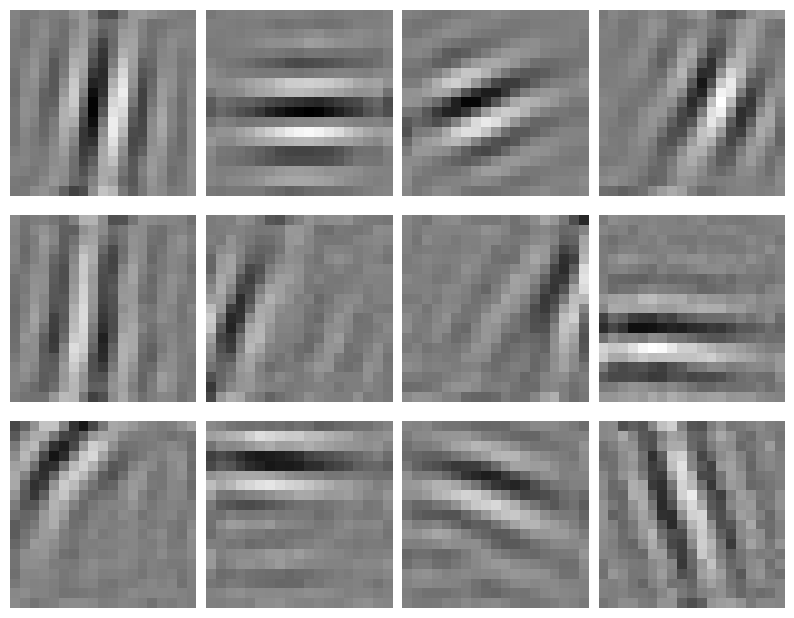

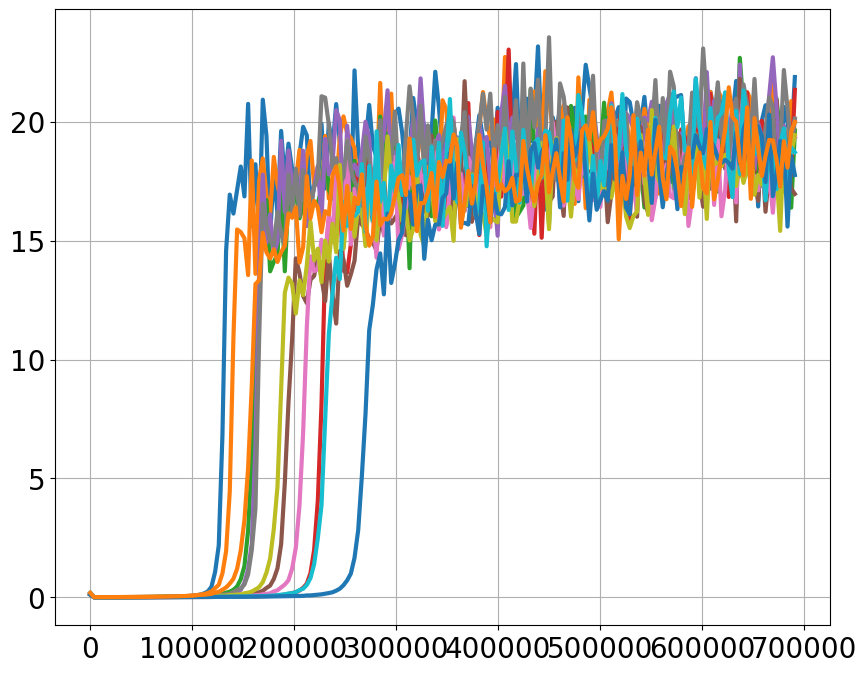

In [7]:
neurons,connections=[pre,post],[c]

c=connections[0]

weights=c.weights
num_neurons=len(weights)
rf_size=neurons[0].rf_size

W=weights.reshape((num_neurons,
                    1,
                    rf_size,rf_size))

vmin,vmax=W.min(),W.max()

count=0
blocks=[]
for row in range(3):
    block_row=[]
    for col in range(4):
        rf=W[count,0,:,:]
        block_row.append(rf)
        if col<4-1:
            block_row.append(vmax*ones((rf_size,1)))

        count+=1

    blocks.append(block_row)

    if row<3-1:
        block_row=[]
        for col in range(4):
            block_row.append(vmax*ones((2,rf_size)))
            if col<4-1:
                block_row.append(vmax*ones((2,1)))
        blocks.append(block_row)


im=np.block(blocks)

figure()
imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
grid(None)
axis('off')

figure()
t,θ=sim.monitors['theta'].arrays()
plot(t,θ);

In [8]:
R=Results(sfname)

In [9]:
subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]


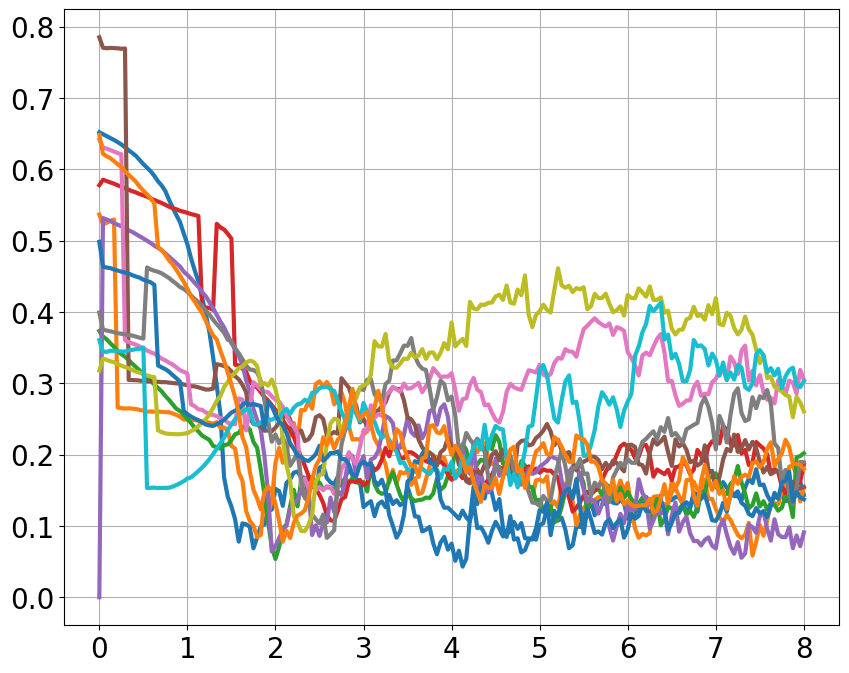

In [10]:
plot(subR.t,subR.LSFV[:,:,0]);

In [11]:
t,y=R.all_responses[0]
y.shape   # SF, theta, channels, neurons, time

(20, 24, 1, 12, 193)

In [12]:
# end time
y=y[:,:,:,:,-1]
y.shape

(20, 24, 1, 12)

In [13]:
idx=[]
for n in range(y.shape[3]):
    idx+=[argmax(y[:,:,0,n])]  # max across all angles and SF
idx

[397, 407, 404, 399, 396, 374, 375, 384, 376, 408, 386, 393]

In [14]:
theta_mat=subR.theta_mat
k_mat=subR.k_mat
len(theta_mat),len(k_mat)

(24, 20)

In [15]:
i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
_S=Storage()

max_k_idx=[]
max_theta_idx=[]

for n in range(y.shape[3]):
    max_k_idx=j.ravel()[idx[n]]
    max_theta_idx=i.ravel()[idx[n]]
    max_k=k_mat[max_k_idx]
    max_theta=theta_mat[max_theta_idx]

    _S+=max_k,max_theta,max_k_idx,max_theta_idx

max_k,max_theta,max_k_idx,max_theta_idx=_S.arrays()
max_k,max_theta

(array([1.2296992 , 1.2296992 , 1.2296992 , 1.2296992 , 1.2296992 ,
        0.95256167, 0.95256167, 1.2296992 , 0.95256167, 1.5874669 ,
        1.2296992 , 1.2296992 ]),
 array([101.73913043, 180.        , 156.52173913, 117.39130435,
         93.91304348, 109.56521739, 117.39130435,   0.        ,
        125.2173913 ,   0.        ,  15.65217391,  70.43478261]))

Text(0.5, 1.0, 'Mean SF 3.60 cpd')

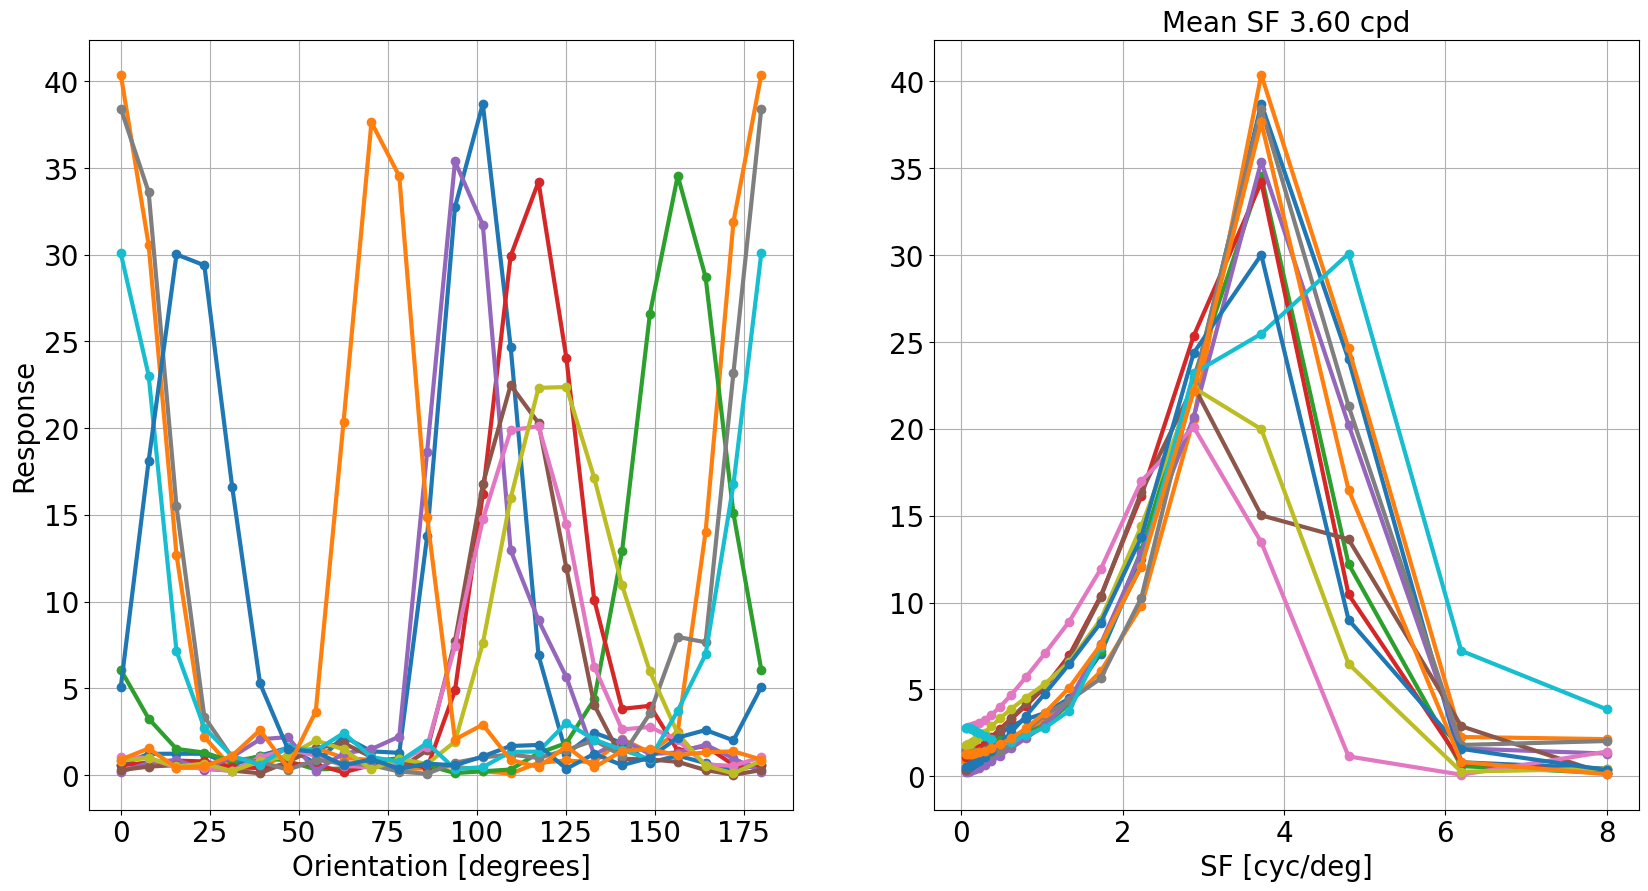

In [16]:
figure(figsize=(20,10))
subplot(1,2,1)

for n in range(y.shape[3]):
    plot(theta_mat,y[:,:,0,n][max_k_idx[n],:],'-o')
xlabel('Orientation [degrees]')
ylabel('Response')

cpd=k_mat/(2*pi*deg_per_pixel)
max_cpd=max_k/(2*pi*deg_per_pixel)
subplot(1,2,2)
for n in range(y.shape[3]):
    plot(cpd,y[:,:,0,n][:,max_theta_idx[n]],'-o')

xlabel('SF [cyc/deg]')
title(f'Mean SF {mean(max_cpd):.2f} cpd')

In [17]:
y.shape

(20, 24, 1, 12)

In [18]:
rf_diameter=rf_size
cpd=2**linspace(-4,3,20)
deg_per_pixel=1/rf_diameter  # <=============
k_mat=2*pi*cpd*deg_per_pixel


In [19]:
k_mat

array([0.02066837, 0.02668161, 0.03444434, 0.04446555, 0.05740232,
       0.0741029 , 0.09566234, 0.12349427, 0.15942359, 0.20580616,
       0.26568324, 0.34298091, 0.4427675 , 0.57158593, 0.73788268,
       0.95256167, 1.2296992 , 1.5874669 , 2.04932325, 2.64555171])

In [20]:
cpd

array([0.0625    , 0.0806837 , 0.10415775, 0.13446132, 0.17358139,
       0.22408302, 0.28927756, 0.37343974, 0.482088  , 0.62234629,
       0.80341123, 1.03715504, 1.3389041 , 1.72844379, 2.23131584,
       2.88049308, 3.71854142, 4.80041088, 6.19703857, 8.        ])

## Loop it

In [21]:
@ray.remote
def doit_1RF_blur(blur):

    
    dt=200*ms
    rf_size=19
    eta=4e-6
    b=blur
    
    seq=pn.Sequence()

    if blur>=0:
        im=pi5.filtered_images(
                            base_image_file,
                            {'type':'blur','size':b},
                            {'type':'norm'},
                            {'type':'dog','sd1':1,'sd2':3},verbose=False,   
                            )
    else:
        im=pi5.filtered_images(
                            base_image_file,
                            {'type':'dog','sd1':1,'sd2':3},verbose=False,    
                            )
        
        
    pre1=pn.neurons.natural_images(im,
                                    rf_size=rf_size,
                                    time_between_patterns=dt,
                                                verbose=False)
    
    sigma=0.1
    pre1+=pn.neurons.process.add_noise_normal(0,sigma)
    
    pre=pre1
    
    number_of_neurons=12

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta
    
    total_time=8*day
    save_interval=1*hour
        
    sim=pn.simulation(total_time)
    sim.dt=dt
    
    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)
    
    rf_diameter=rf_size
    cpd=2**linspace(-4,3,20)
    deg_per_pixel=1/rf_diameter  # <=============
    k_mat=2*pi*cpd*deg_per_pixel
        
    sim+=pn.grating_response(print_time=False,
                        k_mat=k_mat,
                            )
    
    
    seq+=sim,[pre,post],[c]
    
    
    seq.run(display_hash=False)
    
    final_weights=c.weights.copy()
    
    sfname=f"{base_sim_dir}/rf1_blur_{blur:.1f}.asdf"
    pn.save(sfname,seq) 

    return sfname

In [22]:
arange(0,6.1,0.25)

array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 ,
       2.75, 3.  , 3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 , 4.75, 5.  , 5.25,
       5.5 , 5.75, 6.  ])

In [23]:
results = [doit_1RF_blur.remote(b) for b in [-1]+list(arange(0,6.2,.25))]
sfnames=ray.get(results)
sfnames

['sims-2025-04-06/rf1_blur_-1.0.asdf',
 'sims-2025-04-06/rf1_blur_0.0.asdf',
 'sims-2025-04-06/rf1_blur_0.2.asdf',
 'sims-2025-04-06/rf1_blur_0.5.asdf',
 'sims-2025-04-06/rf1_blur_0.8.asdf',
 'sims-2025-04-06/rf1_blur_1.0.asdf',
 'sims-2025-04-06/rf1_blur_1.2.asdf',
 'sims-2025-04-06/rf1_blur_1.5.asdf',
 'sims-2025-04-06/rf1_blur_1.8.asdf',
 'sims-2025-04-06/rf1_blur_2.0.asdf',
 'sims-2025-04-06/rf1_blur_2.2.asdf',
 'sims-2025-04-06/rf1_blur_2.5.asdf',
 'sims-2025-04-06/rf1_blur_2.8.asdf',
 'sims-2025-04-06/rf1_blur_3.0.asdf',
 'sims-2025-04-06/rf1_blur_3.2.asdf',
 'sims-2025-04-06/rf1_blur_3.5.asdf',
 'sims-2025-04-06/rf1_blur_3.8.asdf',
 'sims-2025-04-06/rf1_blur_4.0.asdf',
 'sims-2025-04-06/rf1_blur_4.2.asdf',
 'sims-2025-04-06/rf1_blur_4.5.asdf',
 'sims-2025-04-06/rf1_blur_4.8.asdf',
 'sims-2025-04-06/rf1_blur_5.0.asdf',
 'sims-2025-04-06/rf1_blur_5.2.asdf',
 'sims-2025-04-06/rf1_blur_5.5.asdf',
 'sims-2025-04-06/rf1_blur_5.8.asdf',
 'sims-2025-04-06/rf1_blur_6.0.asdf']

In [24]:
RR={}
for sfname in tqdm(sfnames):
    RR[sfname]=Results(sfname)

100%|███████████████████████████████████████████| 26/26 [00:02<00:00, 11.47it/s]


In [25]:
subResults={}
for sfname in tqdm(sfnames):
    R=RR[sfname]
    
    subR=Struct()
    subR.t=R.t/day
    t=subR.t
    
    subR.y=R.y
    subR.θ=R.θ

    #idx1,idx2=[_[1] for _ in R.sequence_index]

    subR.ORI=R.ORI
    subR.theta_mat=R.theta_mat
    subR.k_mat=R.k_mat
    subR.LSFV=R.LSFV
    subR.SF_Var=R.SF_Var
    subR.max_SF=R.max_SF
    subR.sfname=sfname
    subR.sequence_index=R.sequence_index
    subR.idx=[0]+[_[-1] for _ in R.sequence_index]
    subR.W=R.W[subR.idx,::]
        
    subResults[sfname]=subR

100%|██████████████████████████████████████████| 26/26 [00:00<00:00, 534.89it/s]


In [26]:
blur=-1
sfname=f"{base_sim_dir}/rf1_blur_{blur:.1f}.asdf"

In [27]:
subR=subResults[sfname]

In [28]:
subR.W.shape

(2, 12, 361)

(-0.5, 78.5, 60.5, -0.5)

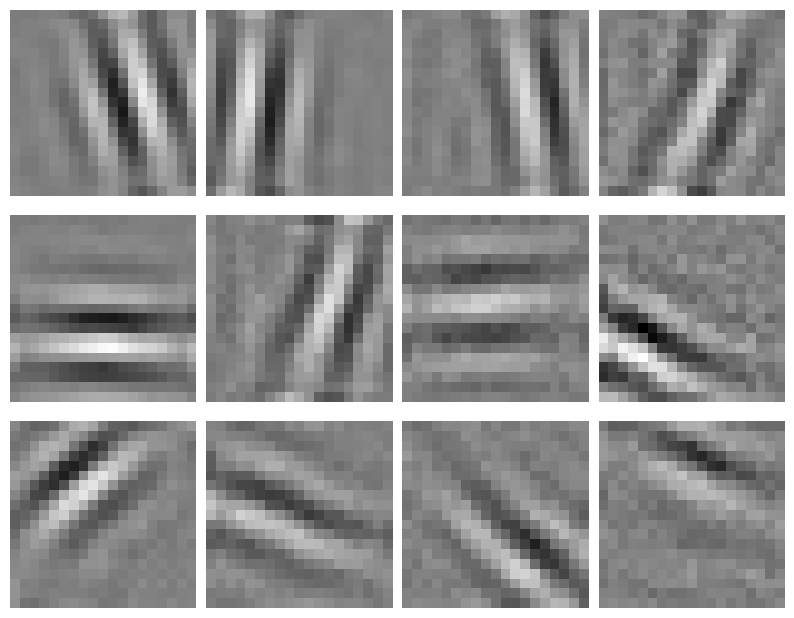

In [29]:
weights=subR.W[-1,:,:]
num_neurons=len(weights)
rf_size=neurons[0].rf_size

W=weights.reshape((num_neurons,
                    1,
                    rf_size,rf_size))

vmin,vmax=W.min(),W.max()

count=0
blocks=[]
for row in range(3):
    block_row=[]
    for col in range(4):
        rf=W[count,0,:,:]
        block_row.append(rf)
        if col<4-1:
            block_row.append(vmax*ones((rf_size,1)))

        count+=1

    blocks.append(block_row)

    if row<3-1:
        block_row=[]
        for col in range(4):
            block_row.append(vmax*ones((2,rf_size)))
            if col<4-1:
                block_row.append(vmax*ones((2,1)))
        blocks.append(block_row)


im=np.block(blocks)

figure()
imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
grid(None)
axis('off')

In [38]:
blur_arr=arange(0,6.1,0.25)
blur_arr=blur_arr[:20]

In [39]:
len(arange(0,6.1,0.25))

25

With RF 19 eta 4e-6

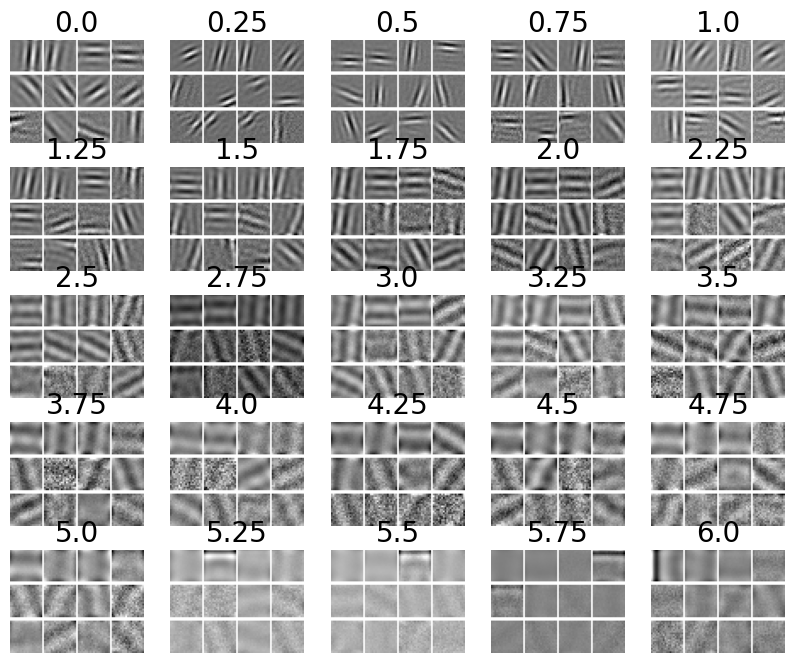

with RF 31 and eta 2e-6 -- no real difference

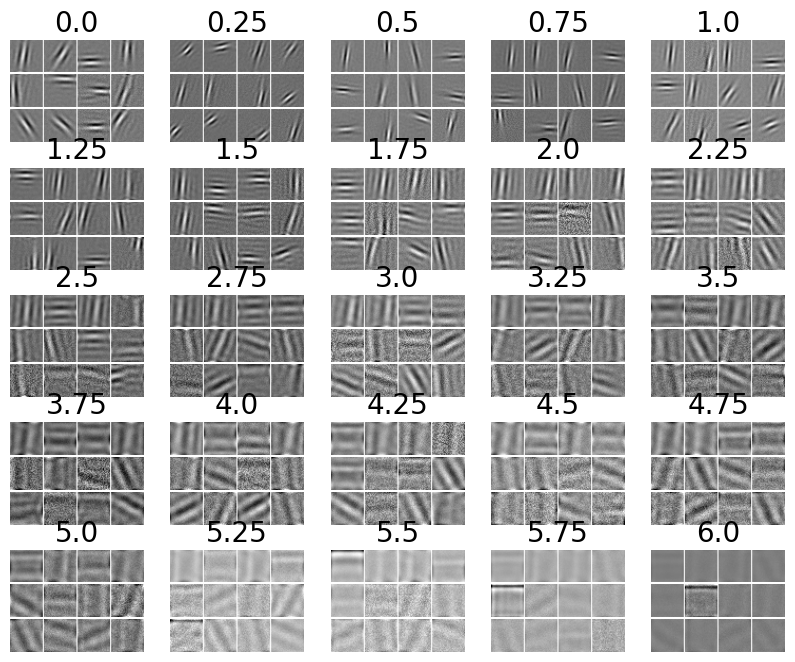

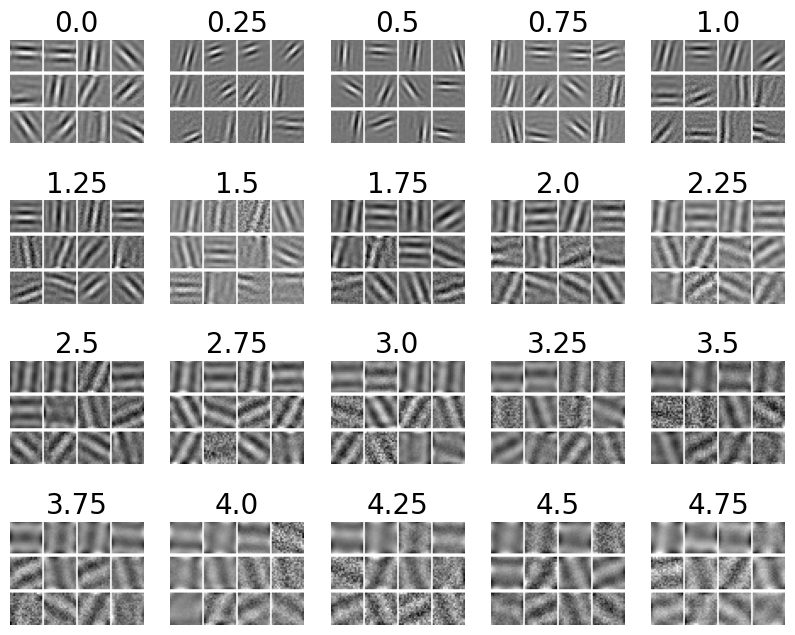

In [40]:
for i,blur in enumerate(blur_arr):
    sfname=f"{base_sim_dir}/rf1_blur_{blur:.1f}.asdf"
    subR=subResults[sfname]


    weights=subR.W[-1,:,:]
    num_neurons=len(weights)
    rf_size=neurons[0].rf_size
    
    W=weights.reshape((num_neurons,
                        1,
                        rf_size,rf_size))
    
    vmin,vmax=W.min(),W.max()
    
    count=0
    blocks=[]
    for row in range(3):
        block_row=[]
        for col in range(4):
            rf=W[count,0,:,:]
            block_row.append(rf)
            if col<4-1:
                block_row.append(vmax*ones((rf_size,1)))
    
            count+=1
    
        blocks.append(block_row)
    
        if row<3-1:
            block_row=[]
            for col in range(4):
                block_row.append(vmax*ones((2,rf_size)))
                if col<4-1:
                    block_row.append(vmax*ones((2,1)))
            blocks.append(block_row)
    
    
    im=np.block(blocks)
    
    subplot(4,5,i+1)
    imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
    grid(None)
    axis('off')
    title(blur)

In [41]:
rf_size

19

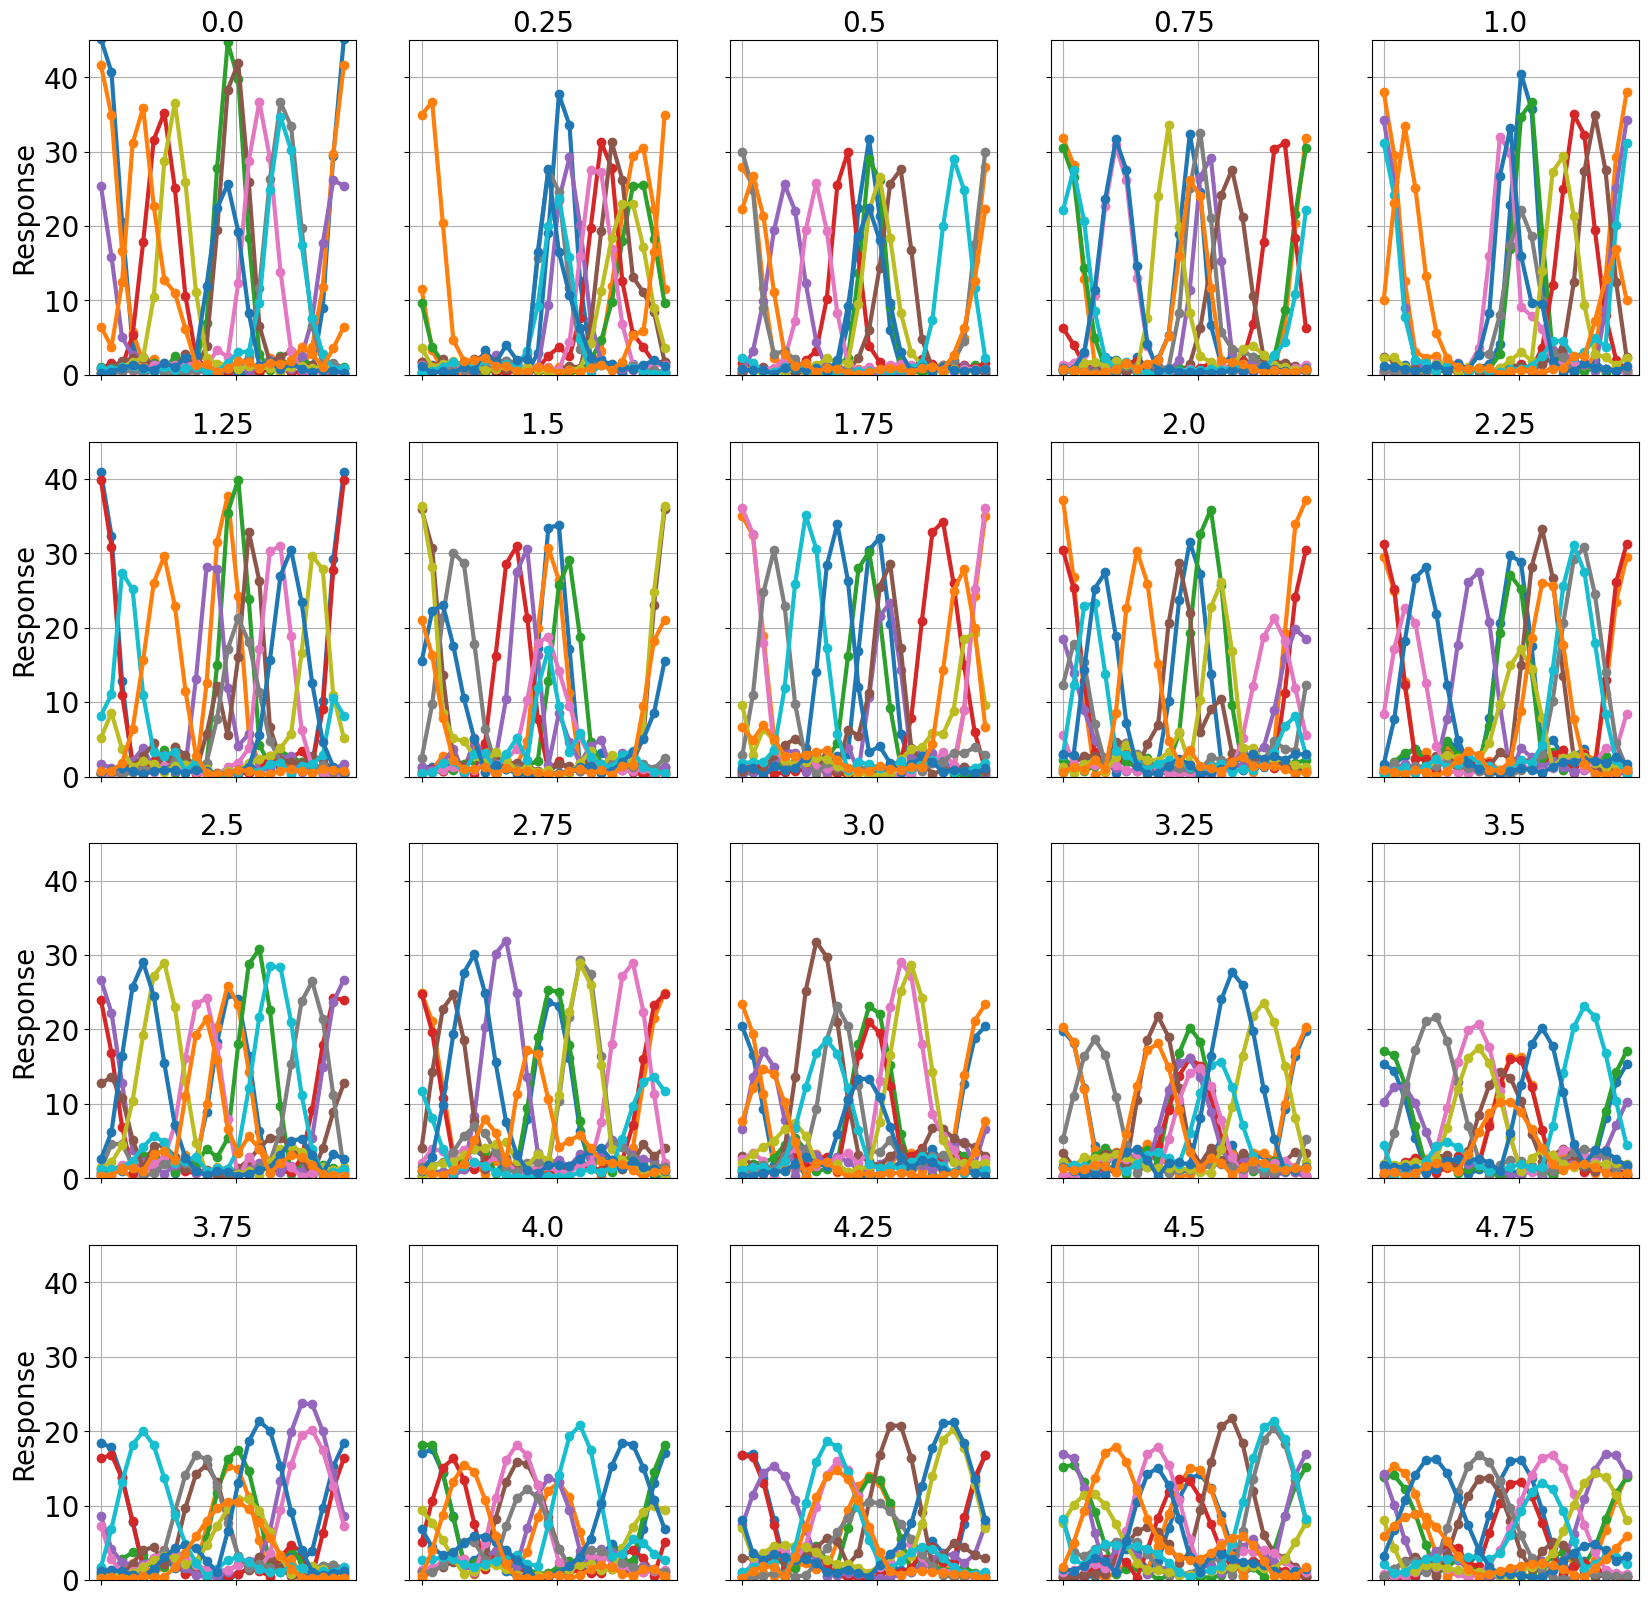

In [42]:
figure(figsize=(20,20))
for bi,blur in enumerate(blur_arr):
    sfname=f"{base_sim_dir}/rf1_blur_{blur:.1f}.asdf"
    subR=subResults[sfname]
    t,y=RR[sfname].all_responses[0]
    y=y[:,:,:,:,-1]  # last time

    idx=[]
    for n in range(y.shape[3]):
        idx+=[argmax(y[:,:,0,n])]  # max across all angles and SF

    theta_mat=subR.theta_mat
    k_mat=subR.k_mat

    i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
    _S=Storage()
    
    max_k_idx=[]
    max_theta_idx=[]
    
    for n in range(y.shape[3]):
        max_k_idx=j.ravel()[idx[n]]
        max_theta_idx=i.ravel()[idx[n]]
        max_k=k_mat[max_k_idx]
        max_theta=theta_mat[max_theta_idx]
    
        _S+=max_k,max_theta,max_k_idx,max_theta_idx
    
    max_k,max_theta,max_k_idx,max_theta_idx=_S.arrays()
    
    subplot(4,5,bi+1)
    for n in range(y.shape[3]):
        plot(theta_mat,y[:,:,0,n][max_k_idx[n],:],'-o')


    if bi in [20,21,22,23,24]:
        xlabel('Orientation [degrees]')
    else:
        gca().set_xticklabels([])

    gca().set_ylim([0,45])
    
    if bi in [0,5,10,15,20]:
        ylabel('Response')
    else:
        gca().set_yticklabels([])

    title(blur)

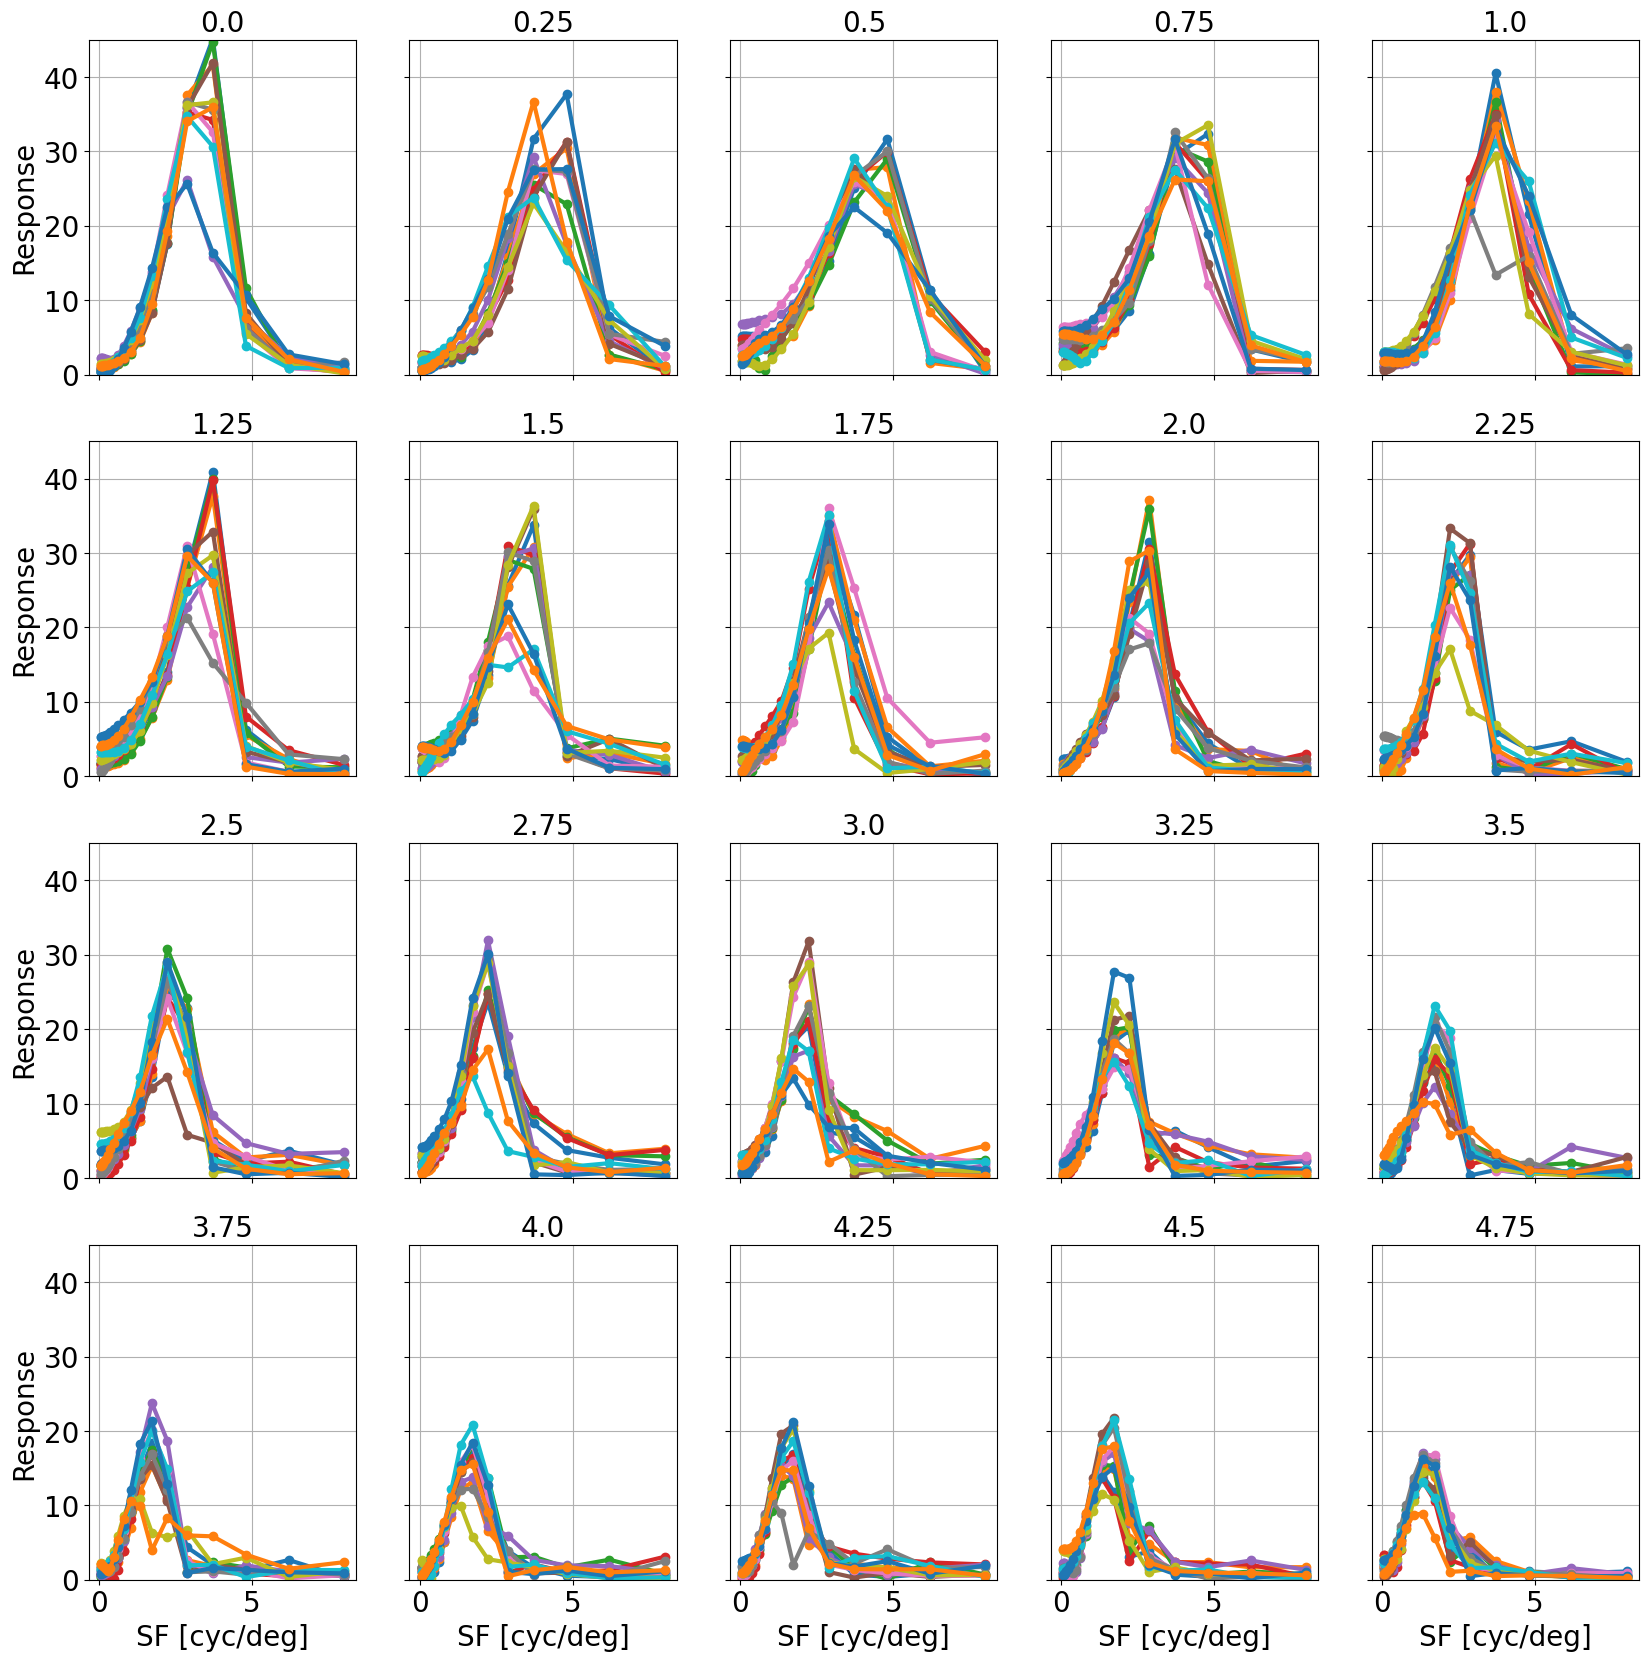

In [45]:
figure(figsize=(20,20))
_S2=Storage()

for bi,blur in enumerate(blur_arr):
    sfname=f"{base_sim_dir}/rf1_blur_{blur:.1f}.asdf"
    subR=subResults[sfname]
    t,y=RR[sfname].all_responses[0]
    y=y[:,:,:,:,-1]  # last time

    idx=[]
    for n in range(y.shape[3]):
        idx+=[argmax(y[:,:,0,n])]  # max across all angles and SF

    theta_mat=subR.theta_mat
    k_mat=subR.k_mat

    i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
    _S=Storage()
    
    max_k_idx=[]
    max_theta_idx=[]
    
    for n in range(y.shape[3]):
        max_k_idx=j.ravel()[idx[n]]
        max_theta_idx=i.ravel()[idx[n]]
        max_k=k_mat[max_k_idx]
        max_theta=theta_mat[max_theta_idx]
    
        _S+=max_k,max_theta,max_k_idx,max_theta_idx
    
    max_k,max_theta,max_k_idx,max_theta_idx=_S.arrays()
    
    subplot(4,5,bi+1)

    cpd=k_mat/(2*pi*deg_per_pixel)
    max_cpd=max_k/(2*pi*deg_per_pixel)
    for n in range(y.shape[3]):
        plot(cpd,y[:,:,0,n][:,max_theta_idx[n]],'-o')
    
    if bi in [15,16,17,18,19]:
        xlabel('SF [cyc/deg]')
    else:
        gca().set_xticklabels([])

    gca().set_ylim([0,45])
    
    if bi in [0,5,10,15,20]:
        ylabel('Response')
    else:
        gca().set_yticklabels([])

    title(blur)

    _S2+=blur,mean(max_cpd)



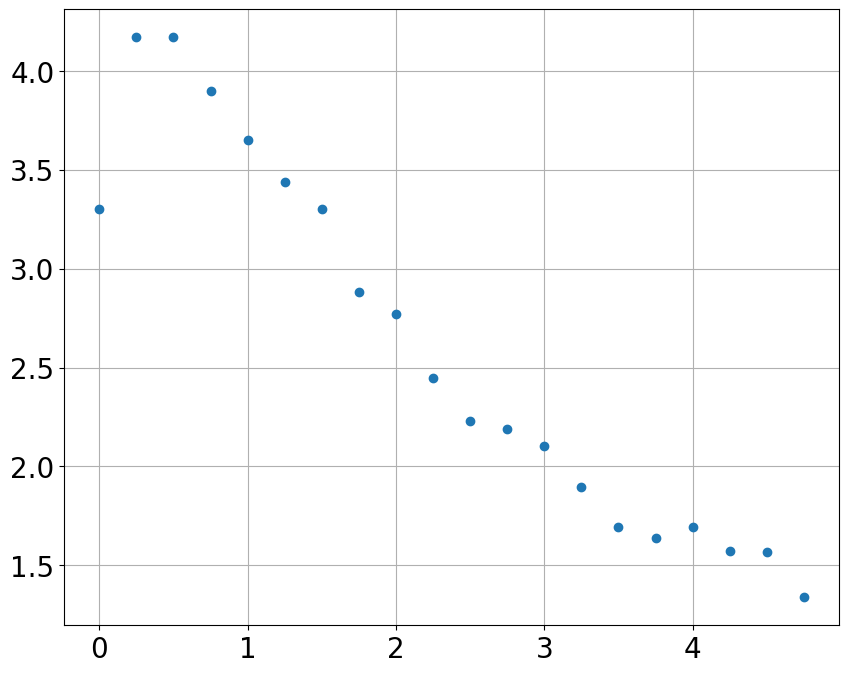

In [47]:
blur,mean_max_cpd=_S2.arrays()
plot(blur,mean_max_cpd,'o')